During the pandemic, a bike-sharing service had suffered considerable losses in their revenues. As a data scientist on the analytics team, you have been tasked to help with coming up with a business plan to accelerate the company's revenue. The first step in this process is to understand the current demand for shared bikes among the people in the city.

You recommend that the team first try to understand the factors on which the demand for these shared bikes depends. In this lab, we will perform a linear regression to predict the count of total rental bikes, and understand the impact of some contributing factors.

In [1]:
import warnings
warnings.simplefilter('ignore')

import numpy as np
import pandas as pd
from itertools import accumulate
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn import metrics
from sklearn.metrics import mean_squared_error

sns.set_context('notebook')
sns.set_style('white')

In [2]:
raw_dataset = pd.read_csv('day.csv')

In [4]:
raw_dataset.sample(5)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
497,498,2012-05-12,2,1,5,0,6,0,1,0.564167,0.544817,0.480417,0.123133,2622,4807,7429
722,723,2012-12-23,1,1,12,0,0,0,1,0.245833,0.259471,0.515417,0.133083,408,1379,1787
106,107,2011-04-17,2,0,4,0,0,0,1,0.456667,0.445696,0.479583,0.303496,1558,2186,3744
20,21,2011-01-21,1,0,1,0,5,1,1,0.177500,0.157833,0.457083,0.353242,75,1468,1543
33,34,2011-02-03,1,0,2,0,4,1,1,0.186957,0.177878,0.437826,0.277752,61,1489,1550


In [5]:
raw_dataset = raw_dataset.drop(columns=['dteday', 'instant', 'registered', 'casual'])

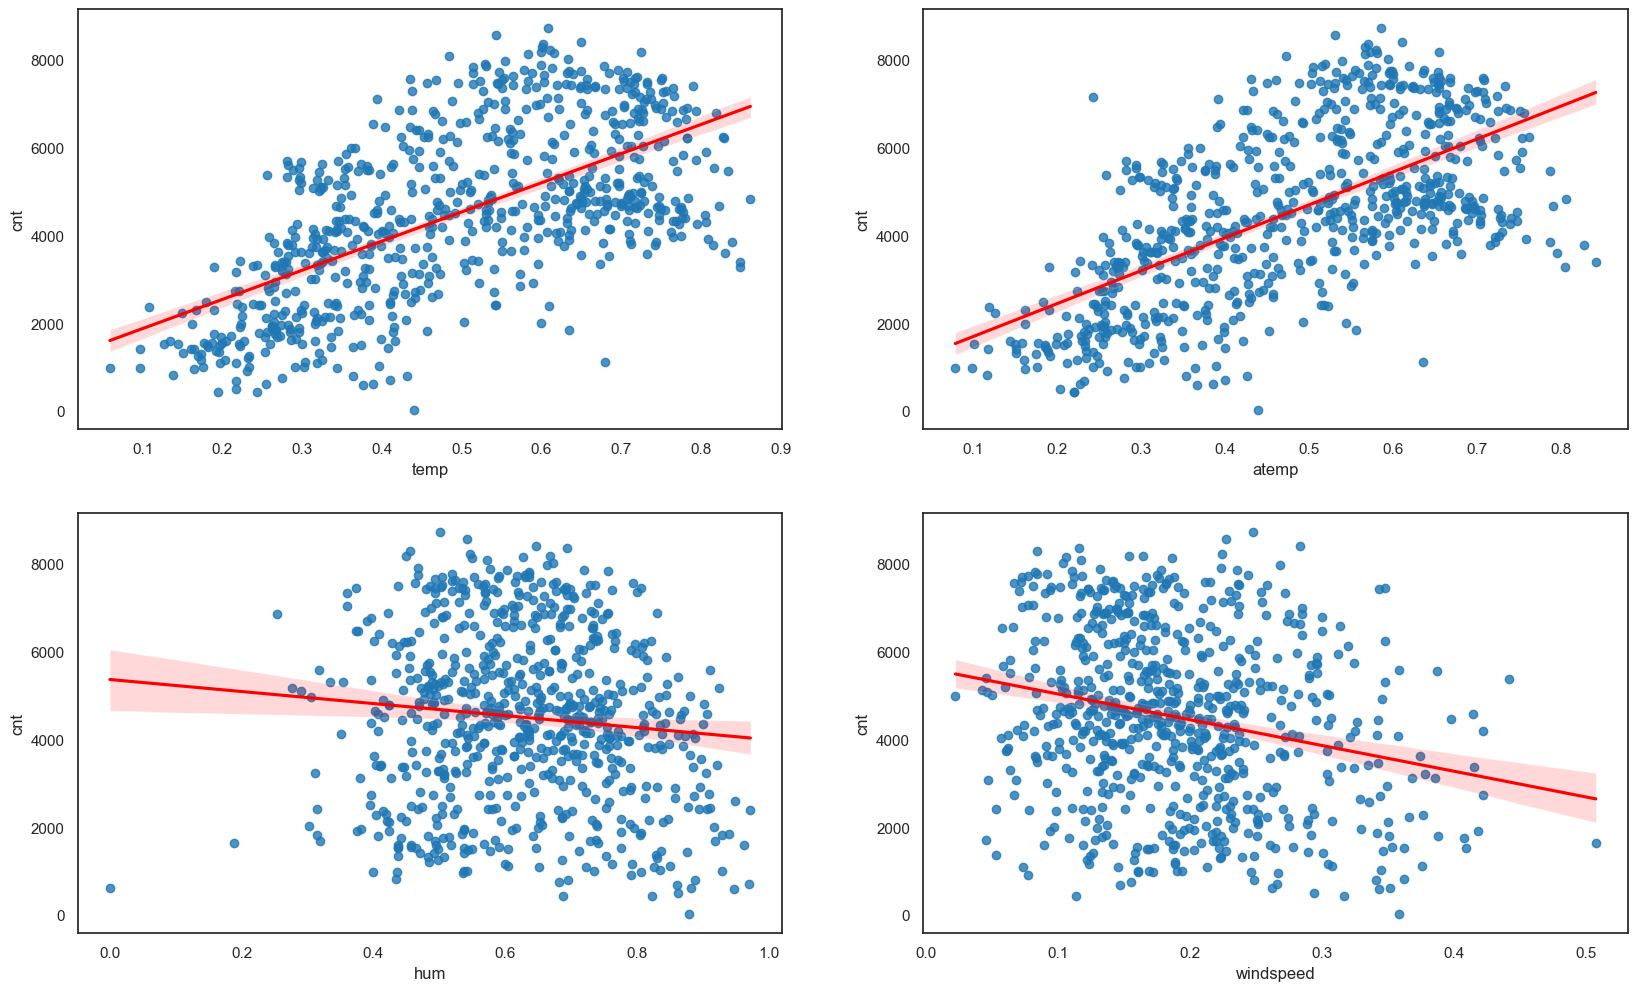

In [6]:
col = ['temp', 'atemp', 'hum', 'windspeed']
plt.figure(figsize=[20,12])
for i in enumerate(col):
    plt.subplot(2,2,i[0]+1)
    sns.regplot(data=raw_dataset,x=i[1],y='cnt',line_kws={"color":'red'})

plt.show()

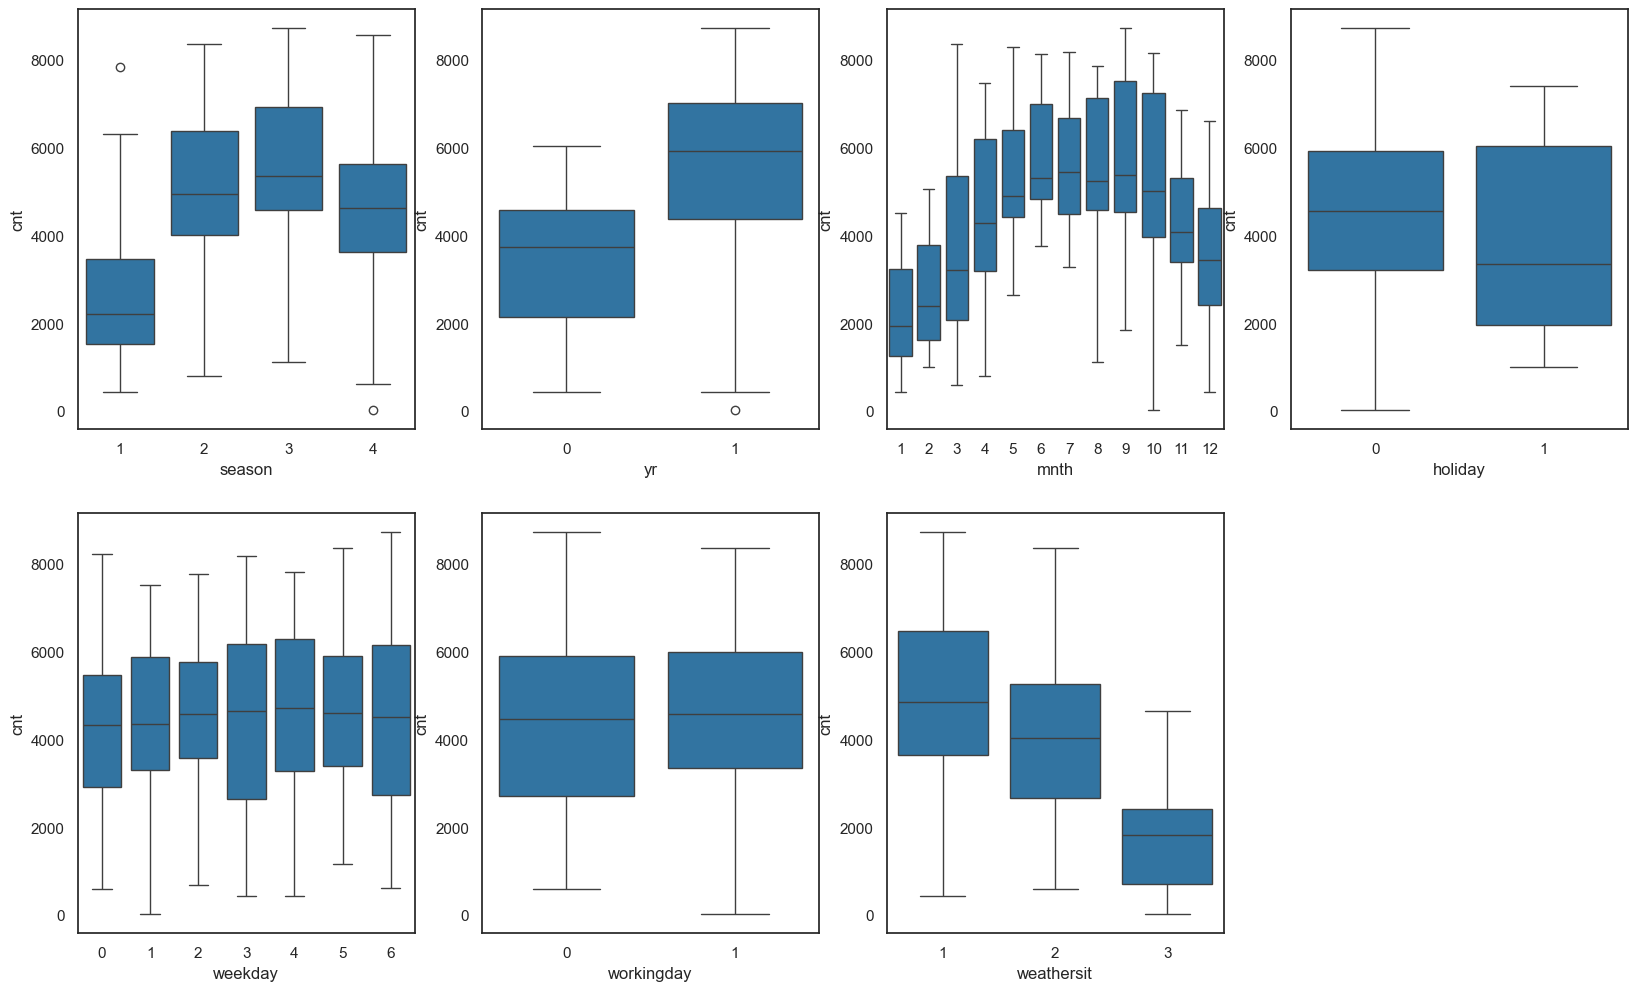

In [7]:
col = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
plt.figure(figsize=[20,12])
for i in enumerate(col):
    plt.subplot(2,4,i[0]+1)
    sns.boxplot(data=raw_dataset,x=i[1],y='cnt')

plt.show()

rental bike demands are the highest during Fall and lowest during Spring.
following is multivariate analysis with pair plot

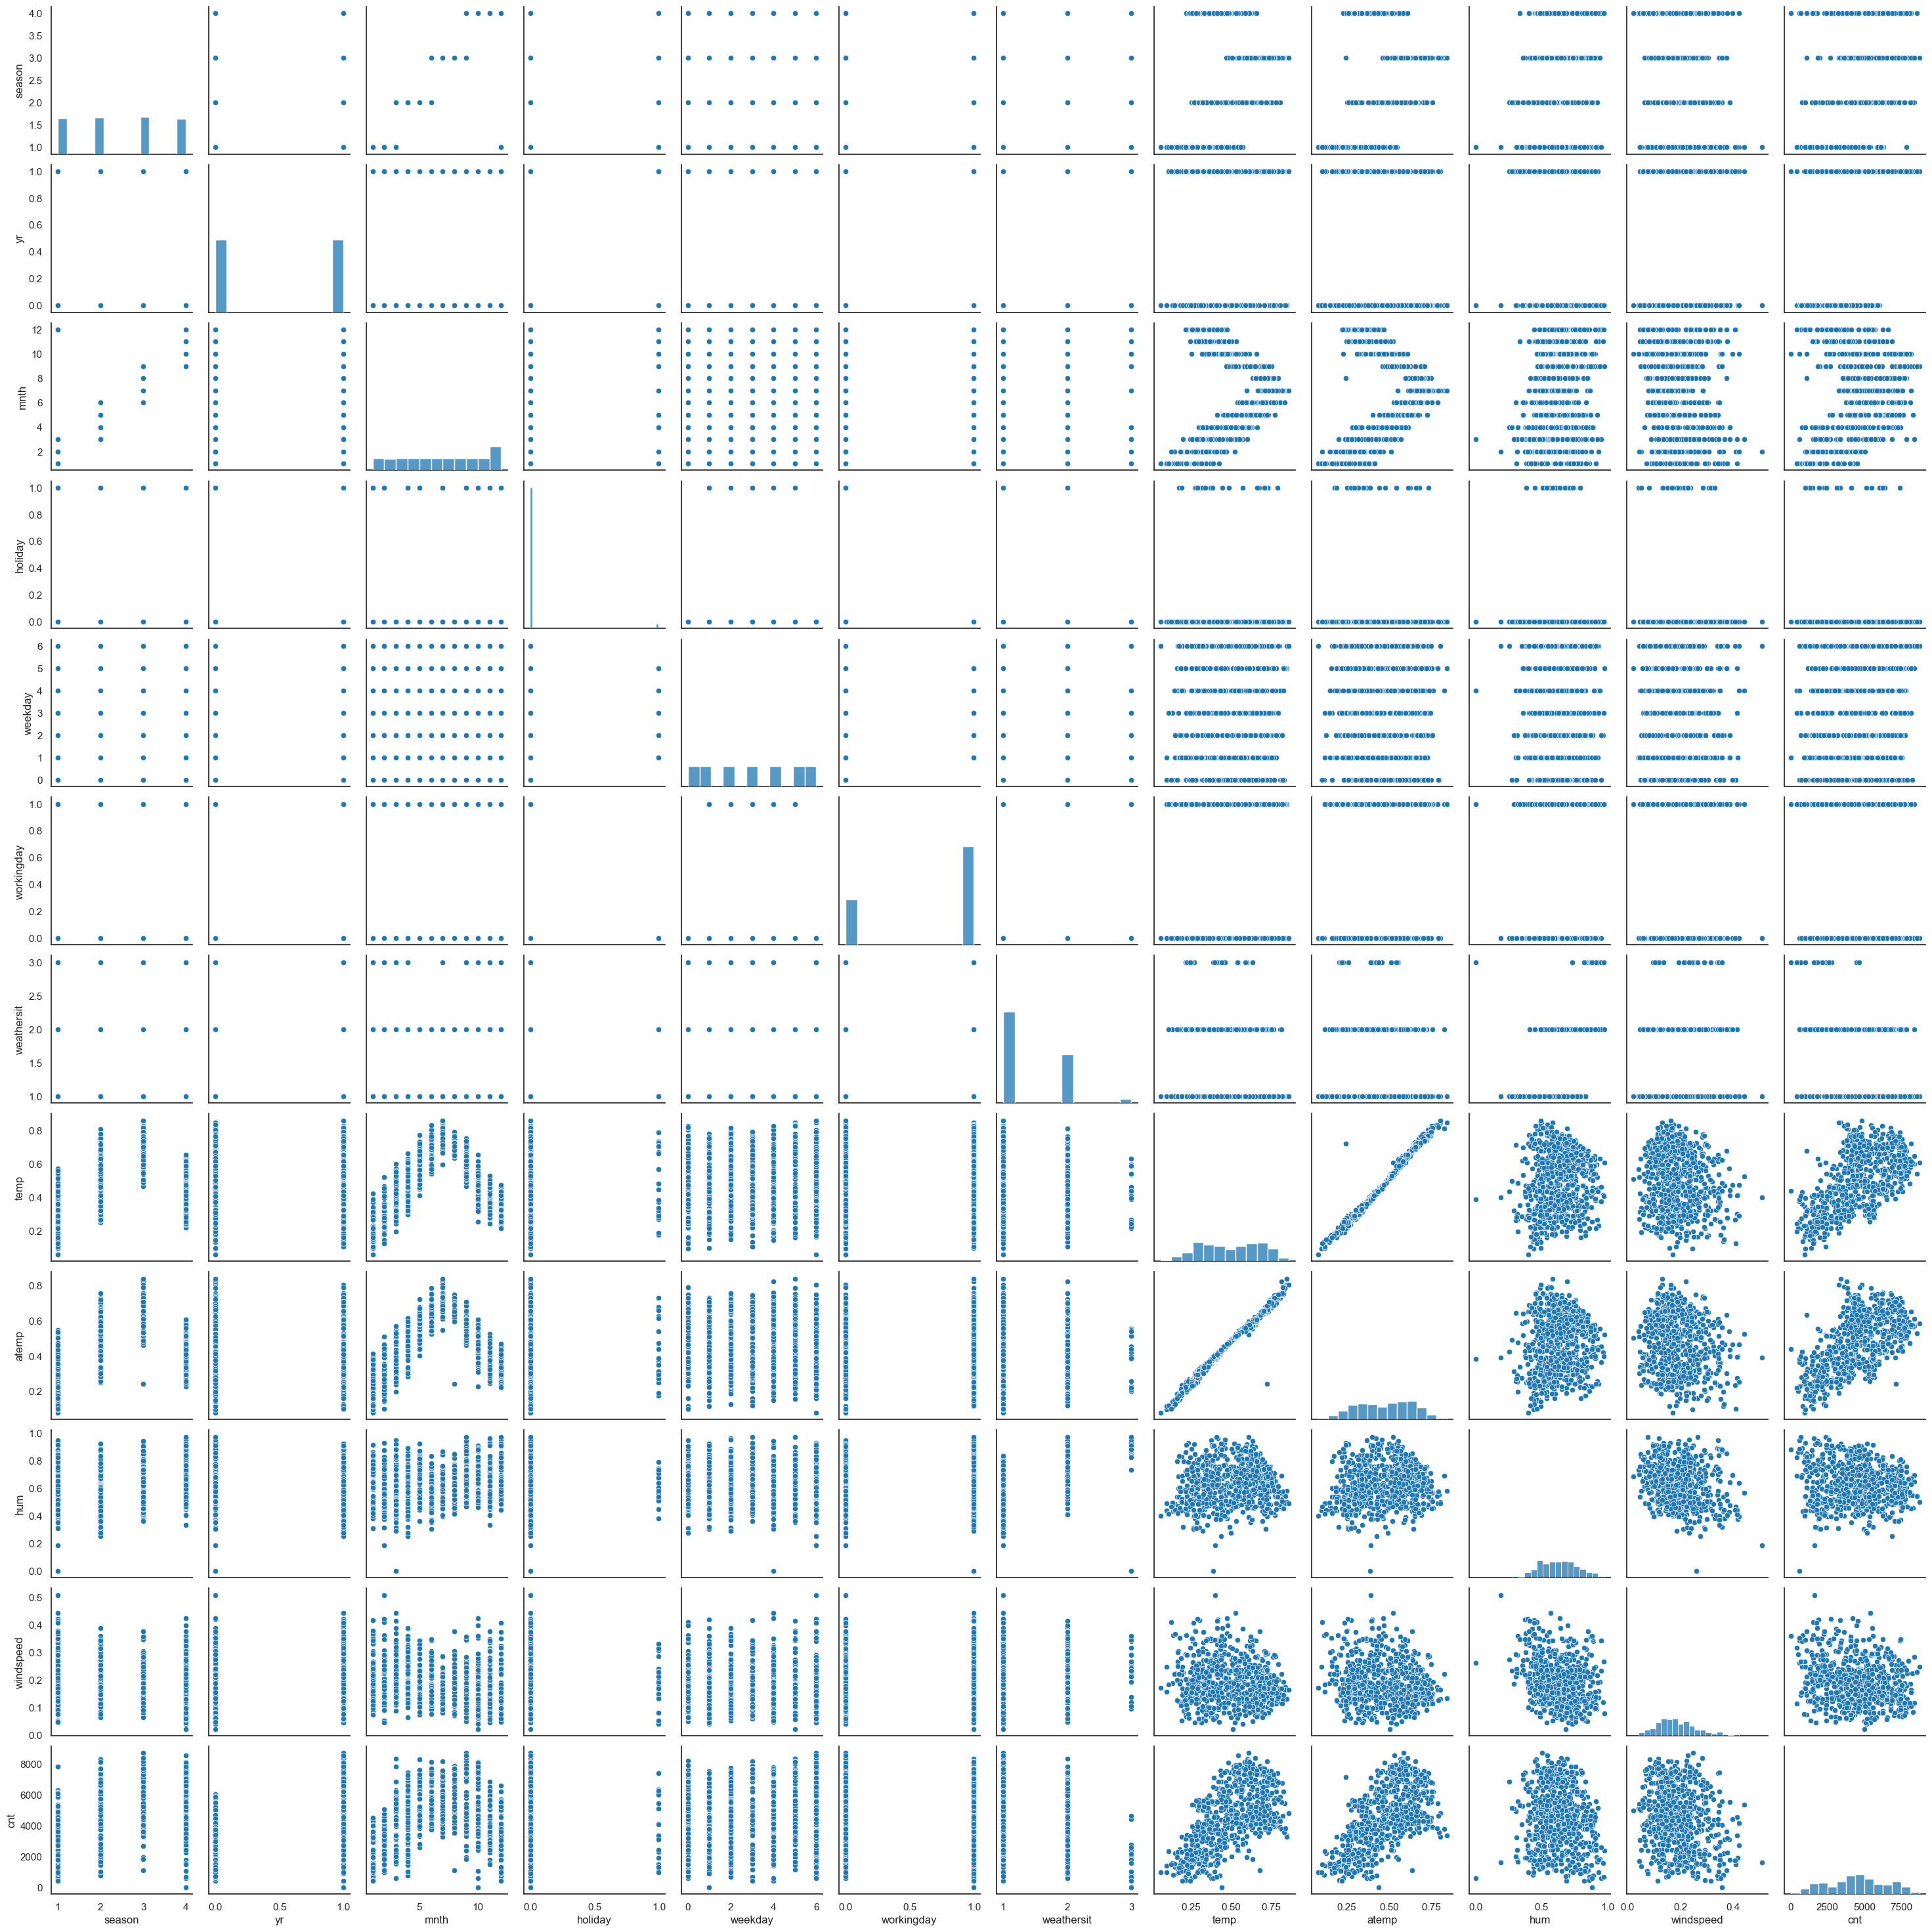

In [8]:
sns.pairplot(raw_dataset)

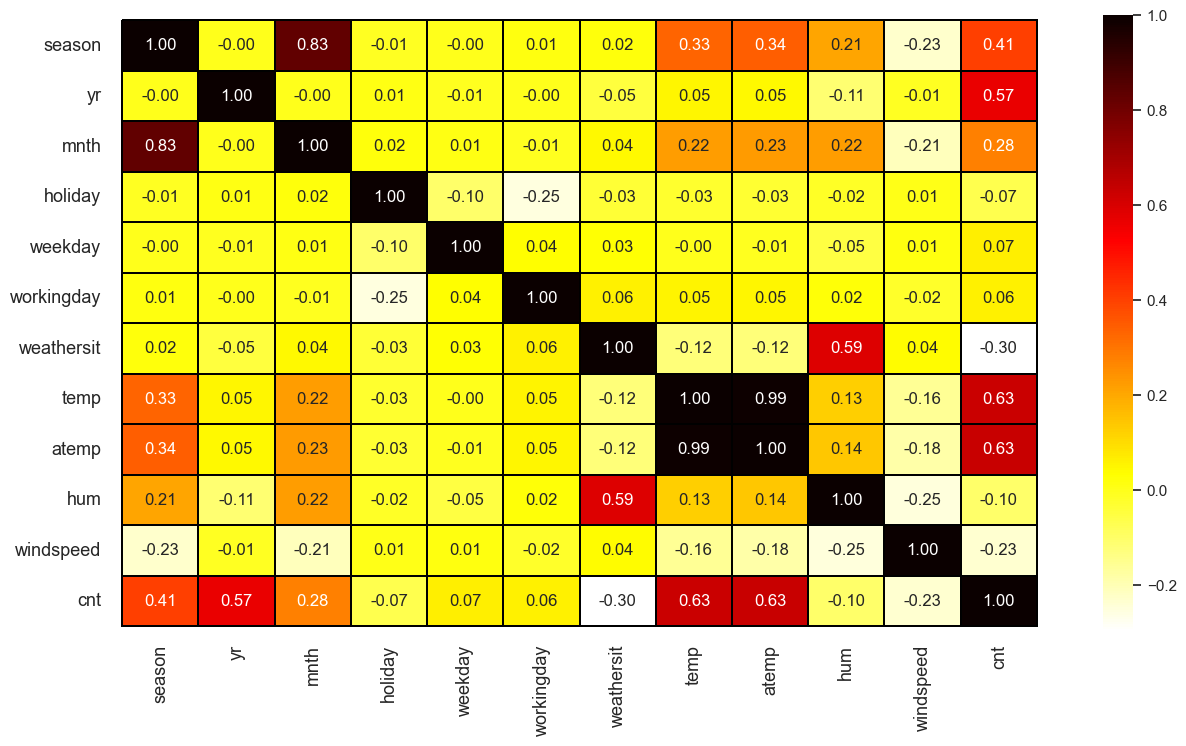

In [9]:
plt.figure(figsize=[15,8])
fig = sns.heatmap(raw_dataset.corr(),cmap='hot_r',
            annot=True,linecolor='black',linewidths=0.01,annot_kws={"fontsize":12},fmt="0.2f")

top, bottom = fig.get_ylim()
fig.set_ylim(top+0.1,bottom-0.1)

left, right = fig.get_xlim()
fig.set_xlim(left-0.1,right+0.1)

plt.yticks(fontsize=13,rotation=0)
plt.xticks(fontsize=13,rotation=90);

A positive correlation between `temp`, `atemp`, `yr` and `cnt` exists, while a negative correlation between `windspeed`, `hum`, `weathersit`, `holiday` and `cnt` exists.

In [10]:
train_dataset = raw_dataset.sample(frac=0.8, random_state=0)
test_dataset = raw_dataset.drop(train_dataset.index)

In [11]:
train_features = train_dataset.copy()
test_features = test_dataset.copy()

train_labels = train_features.pop('cnt')
test_labels = test_features.pop('cnt')

In [12]:
normalizer = tf.keras.layers.Normalization(axis=-1)

In [13]:
normalizer.adapt(np.array(train_features))

In [14]:
print(normalizer.mean.numpy())
print(normalizer.variance.numpy())

[[2.4820514  0.50598294 6.557265   0.02735043 2.9931624  0.6803419
  1.4        0.49609548 0.47542128 0.6289289  0.19085288]]
[[1.2274556e+00 2.4996421e-01 1.1894584e+01 2.6602382e-02 4.0580730e+00
  2.1747680e-01 2.9811966e-01 3.2840721e-02 2.6041929e-02 2.0187266e-02
  6.0876710e-03]]


In [15]:
print(np.array(train_features[:1]))

[[3.       0.       7.       0.       6.       0.       1.       0.686667
  0.638263 0.585    0.208342]]


In [16]:
print(normalizer(np.array(train_features[:1])).numpy())

[[ 0.46750233 -1.0120384   0.12837175 -0.16768871  1.4926226  -1.4588839
  -0.7325962   1.0516028   1.009088   -0.30918026  0.22415186]]


In [17]:
temp = np.array(train_features['temp'])

In [18]:
temp_normalizer = layers.Normalization(input_shape=[1,], axis=None)
temp_normalizer.adapt(temp)

In [19]:
temp_model = tf.keras.Sequential([
    temp_normalizer,
    layers.Dense(units=1)
])
temp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (24.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 3 (16.00 B)

In [20]:
temp_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    loss='mean_squared_error')

In [21]:
history = temp_model.fit(
    train_features['temp'],
    train_labels,
    # to view the logs, uncomment this:
    verbose=False,
    epochs=100,
    # validation split: 20% of the training data.
    validation_split = 0.2)

In [22]:
def plot_loss(history):
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.legend()
    plt.grid(True)

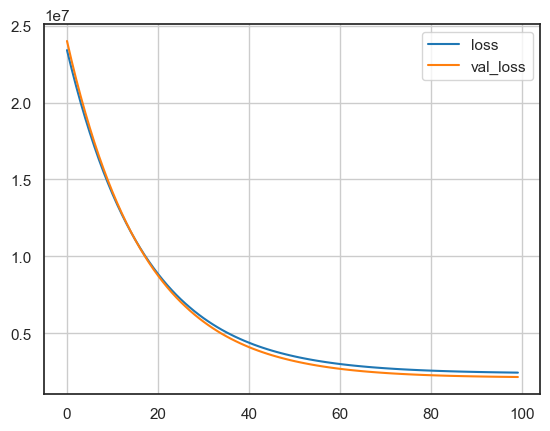

In [23]:
plot_loss(history)

In [24]:
y_pred= temp_model.predict(test_features['temp'])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [25]:
print(np.sqrt(metrics.mean_squared_error(test_labels, y_pred)))

1436.993954406211


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


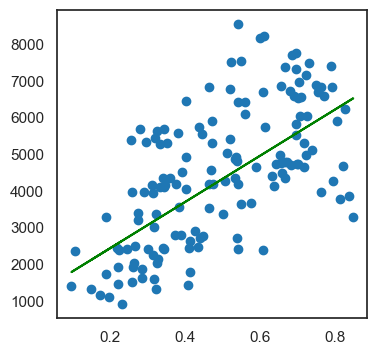

In [26]:
plt.figure(figsize = (4,4))
plt.plot(test_features['temp'], test_labels,'o',
         test_features['temp'],temp_model.predict(test_features['temp']),'g')
plt.show()

In [27]:
linear_model = tf.keras.Sequential([
    normalizer,
    layers.Dense(units=1)
])

In [28]:
linear_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    loss='mean_squared_error')
history = linear_model.fit(
    train_features,
    train_labels,
    epochs=100,
    # to view the logs, uncomment this:
    verbose=0,
    # validation split: 20% of the training data.
    validation_split = 0.2)

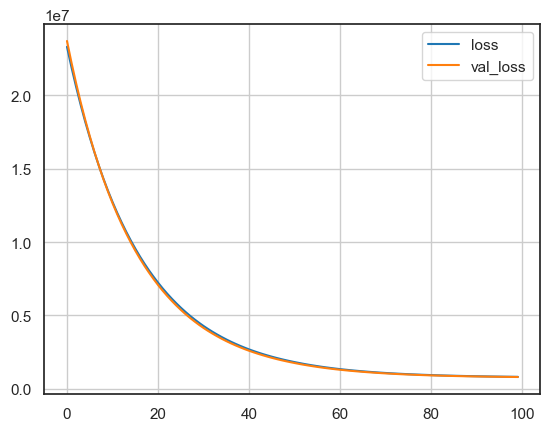

In [29]:
plot_loss(history)

In [30]:
y_pred= linear_model.predict(test_features)
print(np.sqrt(metrics.mean_squared_error(test_labels, y_pred)))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
902.2906266829996


In [31]:
print("Column names")
print(test_features.columns)

# Print weights and biases for each layer
for layer in linear_model.layers:
    print("Layer Name:", layer.name)
    print("---")
    print("Weights")
    print("Shape:",layer.get_weights()[0].shape,'\n',layer.get_weights()[0])
    print("---")
    print("Bias")
    print("Shape:",layer.get_weights()[1].shape,'\n',layer.get_weights()[1],'\n')

Column names
Index(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed'],
      dtype='object')
Layer Name: normalization
---
Weights
Shape: (11,) 
 [2.4820514  0.50598294 6.557265   0.02735043 2.9931624  0.6803419
 1.4        0.49609548 0.47542128 0.6289289  0.19085288]
---
Bias
Shape: (11,) 
 [1.2274556e+00 2.4996421e-01 1.1894584e+01 2.6602382e-02 4.0580730e+00
 2.1747680e-01 2.9811966e-01 3.2840721e-02 2.6041929e-02 2.0187266e-02
 6.0876710e-03] 

Layer Name: dense_1
---
Weights
Shape: (11, 1) 
 [[ 360.2203  ]
 [ 992.56506 ]
 [  48.844433]
 [-135.57065 ]
 [ 154.99287 ]
 [  77.08408 ]
 [-356.12863 ]
 [ 476.67282 ]
 [ 513.22736 ]
 [-163.7972  ]
 [-214.17926 ]]
---
Bias
Shape: (1,) 
 [4292.552] 



UNivariate: use the Iowa Housing dataset where the only feature is SquareFeet, and the target value is SalePrice.

In [32]:
df = pd.read_csv('/Users/fatimarahimi/Desktop/rose-sproj/code/DL_with_Keras/IowaHousingPrices.csv')

In [33]:
x_train = df[['SquareFeet']].values[1:-500]
y_train = df[['SalePrice']].values[1:-500]
x_test = df[['SquareFeet']].values[-500:]
y_test = df[['SalePrice']].values[-500:]

In [34]:
output_size=1
hidden_layer=500
input_size=1
learning_rate=0.51
loss_function='mean_squared_error'
epochs=30
batch_size=10

In [35]:
model = keras.Sequential()
model.add(keras.layers.Dense(hidden_layer,  activation='relu'))

model.add(keras.layers.Dense(output_size))

In [37]:
model.compile(keras.optimizers.Adam(learning_rate=learning_rate), loss_function)

In [38]:
model.fit(x_train, y_train, epochs = epochs, batch_size = batch_size)

Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 504us/step - loss: 5892174848.0000  
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step - loss: 4987944960.0000
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step - loss: 3233731328.0000
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 515us/step - loss: 3434489856.0000
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 485us/step - loss: 3544220928.0000
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 509us/step - loss: 3807795712.0000
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 526us/step - loss: 3396558336.0000
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 486us/step - loss: 3451017984.0000
Epoch 9/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 496us/step - loss: 3377636352.0000
Epoch 10/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 487us/step - loss: 3390910976.0000
Epoch 11/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 478us/step - loss: 3399308800.0000
Epoch 12/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 491us/step - loss: 3147993344.0000
Epoch 13/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - loss: 3161088768.0000
Epoch 

In [39]:
x=np.arange(x_test.min(),x_test.max(),10).reshape(-1,1)

In [40]:
y_pred = model.predict(x)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


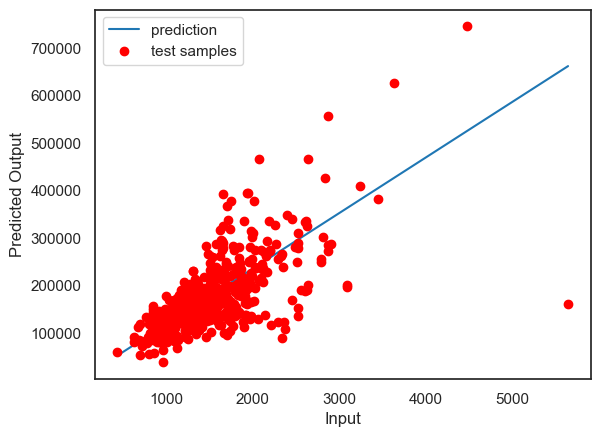

In [41]:
plt.plot(x,y_pred,label="prediction ")
plt.plot(x_test,y_test,'ro',label="test samples")
plt.xlabel('Input')
plt.ylabel('Predicted Output')
plt.legend()
plt.show()

In [50]:
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight','Acceleration', 'Model Year', 'Origin']
data = pd.read_csv('/Users/fatimarahimi/Desktop/rose-sproj/code/DL_with_Keras/auto-mpg.data', names=column_names,na_values='?', comment='\t', sep=' ', skipinitialspace=True)

In [51]:
data

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1


In [52]:
data = data.dropna()

In [54]:
data = data.drop(columns=['Origin'])

In [58]:
train_data = data.sample(frac=0.8, random_state=0)
test_data = data.drop(train_data.index)

train_features = train_data.copy()
test_features = test_data.copy()

train_labels = train_features.pop('MPG')
test_labels = test_features.pop('MPG')



In [59]:
normalizer = tf.keras.layers.Normalization(axis=-1)

In [60]:
normalizer.adapt(np.array(train_features))

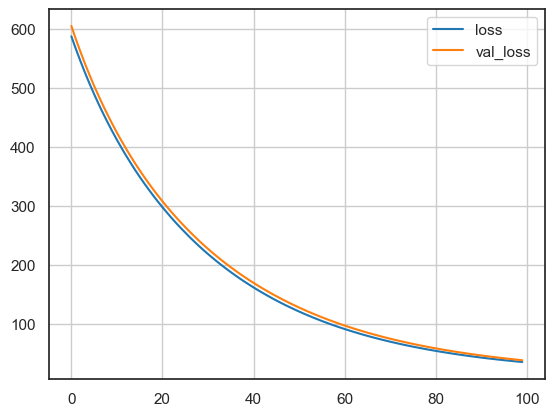

In [62]:
linear_model = tf.keras.Sequential([
    normalizer,
    layers.Dense(units=1)
])
linear_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    loss='mean_squared_error')

history = linear_model.fit(
    train_features,
    train_labels,
    epochs=100,
    verbose=0,
    validation_split = 0.2)

plot_loss(history)

In [63]:
y_pred= linear_model.predict(test_features)
print(np.sqrt(metrics.mean_squared_error(test_labels, y_pred)))


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
5.997450630575085
